In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

In [7]:
df = pd.read_csv('00_titanic.csv')
df.sample(5)
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
num_imp = SimpleImputer(strategy='median')
df[['Age']] = num_imp.fit_transform(df[['Age']])
cat_imp = SimpleImputer(strategy='most_frequent')
df[['Embarked']] = cat_imp.fit_transform(df[['Embarked']])

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
target = ['Survived']

In [43]:
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model = DecisionTreeClassifier()
# model.fit(X_train, y_train)
# y_train_pred = model.predict(X_train)
# y_test_pred = model.predict(X_test)

# print(f'train accuracy is: {accuracy_score(y_train, y_train_pred)}')
# print(f'test accuracy is: {accuracy_score(y_test, y_test_pred)}')
# train accuracy is: 97.75280898876404%
# test accuracy is: 76.53631284916201%

classifier = DecisionTreeClassifier()
param_grid = {
    'max_depth': [3,4,5,6,7,8,9,10,12,11,13],
    'min_samples_split': [5,10,15,20,25,30]
}

grid_search = GridSearchCV(
    classifier,
    param_grid,
    cv=5,
    scoring='recall'
)

grid_search.fit(X_train, y_train)
y_train_pred = grid_search.predict(X_train)
y_test_pred = grid_search.predict(X_test)

print(f'train accuracy is: {accuracy_score(y_train, y_train_pred)}')
print(f'test accuracy is: {accuracy_score(y_test, y_test_pred)}')
print(grid_search.best_params_)


train accuracy is: 0.8258426966292135
test accuracy is: 0.7932960893854749
{'max_depth': 3, 'min_samples_split': 25}


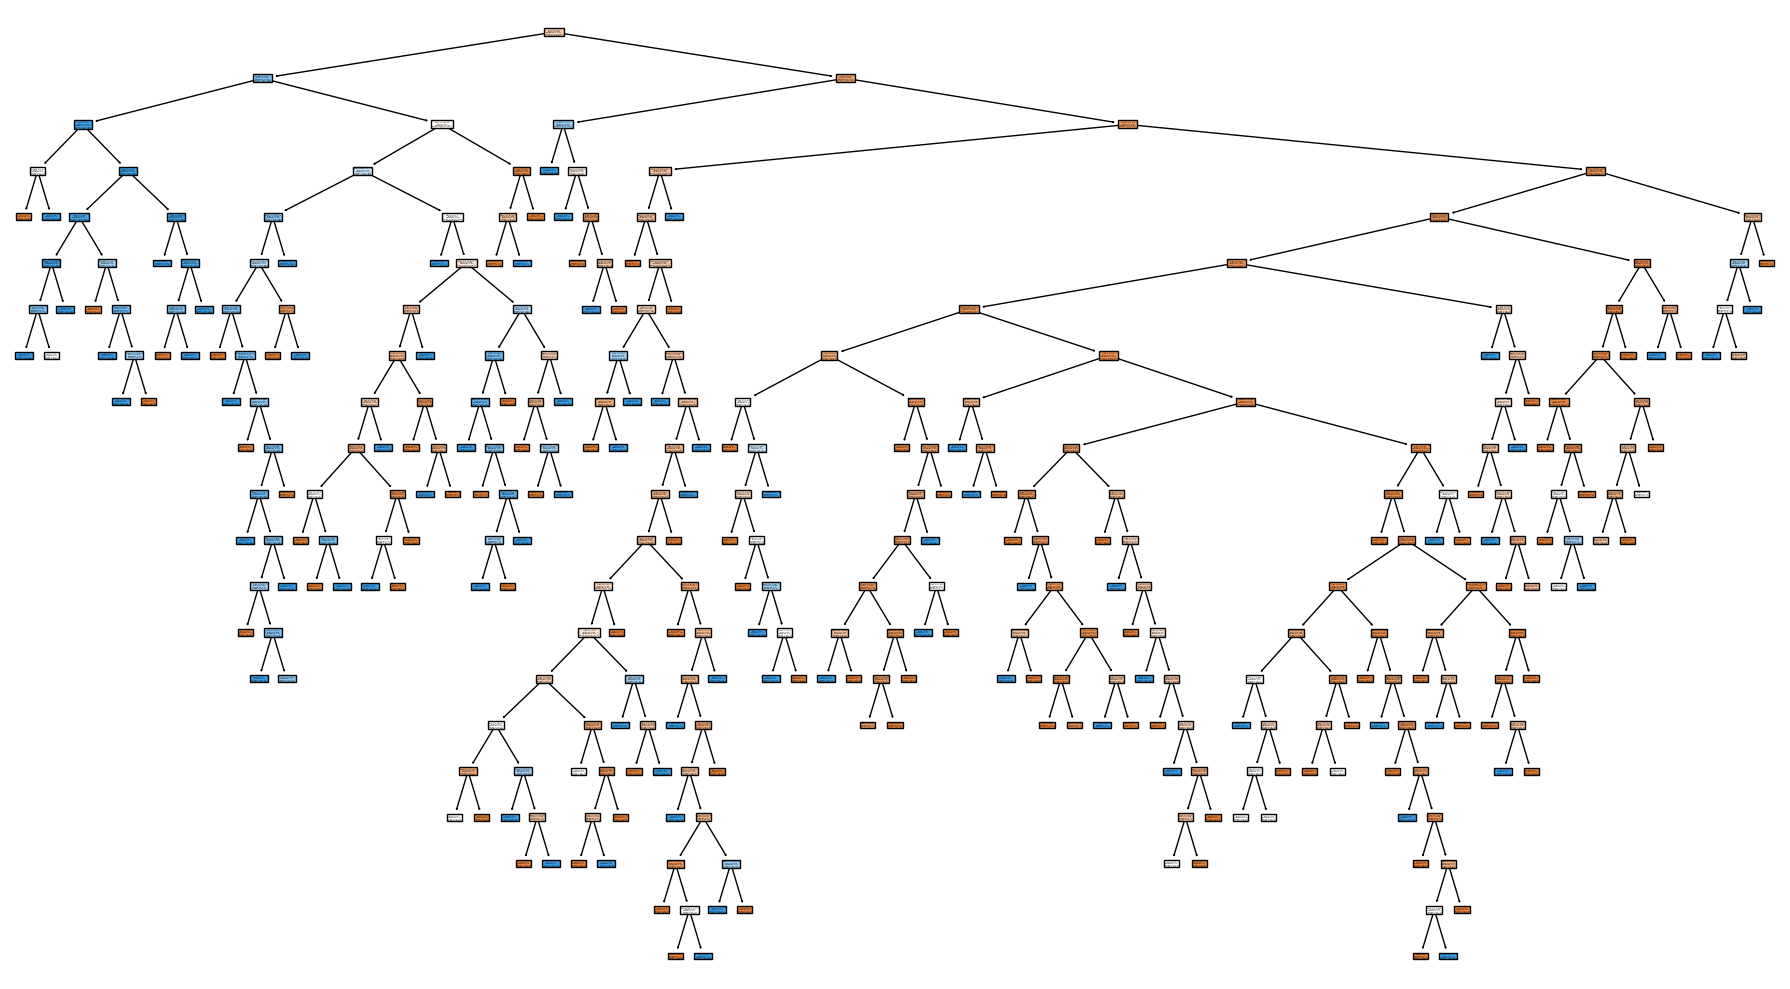

In [37]:
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Died', 'Survived'],
    filled=True
)
plt.tight_layout()
plt.show()

In [38]:
#random forest

from sklearn.ensemble import RandomForestClassifier

In [48]:
rf = RandomForestClassifier(
    n_estimators=201,
    oob_score=True
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f'OOB score : {rf.oob_score_*100}%')
print(f'Testing Accuracy : {accuracy_score(y_test, y_pred)*100}%')

OOB score : 80.6179775280899%
Testing Accuracy : 79.88826815642457%
